# LOAD DATA

In [ ]:
!pip install kaggle
!pip install kagglehub

In [ ]:
import pandas as pd
import glob
import kagglehub

# Download dataset
path = kagglehub.dataset_download("akashdogra/cic-iot-2023")

files = glob.glob(path + "/*.csv")

# Load + sample
df_list = []

for file in files:
    df = pd.read_csv(file)
    df = df.sample(20000, random_state=42)
    df_list.append(df)

data = pd.concat(df_list, ignore_index=True)

# Cleaning
data = data.dropna()

print("Dataset shape:", data.shape)

Resuming download from 1971322880 bytes (1005856370 bytes left)...
Resuming download to C:\Users\Shivank\.cache\kagglehub\datasets\akashdogra\cic-iot-2023\1.archive (1971322880/2977179250) bytes left.


 69%|██████▉   | 1.92G/2.77G [02:33<19:52, 772kB/s]

# LABEL ENCODING

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])

# BASELINE MODEL (ALL FEATURES)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

X = data.drop("label", axis=1)
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

rf = RandomForestClassifier(n_estimators=50, max_depth=15, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("=== BASELINE MODEL ===")
print("Accuracy:", accuracy_score(y_test, y_pred))

=== BASELINE MODEL ===
Accuracy: 0.9913920118343196


# FEATURE SELECTION COMPARISON CODE

In [ ]:
# ================= FEATURE SELECTION COMPARISON =================

import pandas as pd
from sklearn.metrics import accuracy_score

# Get feature importance
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

print("Total Features:", len(feature_importance))

# Try different thresholds
thresholds = [0.001, 0.002, 0.005, 0.01, 0.02]

results = []

for t in thresholds:

    # Select features based on threshold
    selected_features = feature_importance[feature_importance > t].index

    X_new = X[selected_features]

    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_new, y,
        test_size=0.2,
        random_state=42
    )

    from sklearn.ensemble import RandomForestClassifier
    rf_temp = RandomForestClassifier(
        n_estimators=50,
        max_depth=15,
        random_state=42
    )

    rf_temp.fit(X_train, y_train)
    y_pred = rf_temp.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append((t, len(selected_features), acc))

    print(f"Threshold: {t} | Features: {len(selected_features)} | Accuracy: {acc}")

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["Threshold", "Features", "Accuracy"])

print("\n=== COMPARISON TABLE ===")
print(results_df)

# Best model
best = results_df.loc[results_df["Accuracy"].idxmax()]

print("\n=== BEST MODEL ===")
print("Best Threshold:", best["Threshold"])
print("Best Features:", best["Features"])
print("Best Accuracy:", best["Accuracy"])

Total Features: 46
Threshold: 0.001 | Features: 32 | Accuracy: 0.9918476331360947
Threshold: 0.002 | Features: 32 | Accuracy: 0.9918476331360947
Threshold: 0.005 | Features: 27 | Accuracy: 0.9911523668639053
Threshold: 0.01 | Features: 24 | Accuracy: 0.9906671597633137
Threshold: 0.02 | Features: 15 | Accuracy: 0.9907085798816568

=== COMPARISON TABLE ===
   Threshold  Features  Accuracy
0      0.001        32  0.991848
1      0.002        32  0.991848
2      0.005        27  0.991152
3      0.010        24  0.990667
4      0.020        15  0.990709

=== BEST MODEL ===
Best Threshold: 0.001
Best Features: 32.0
Best Accuracy: 0.9918476331360947


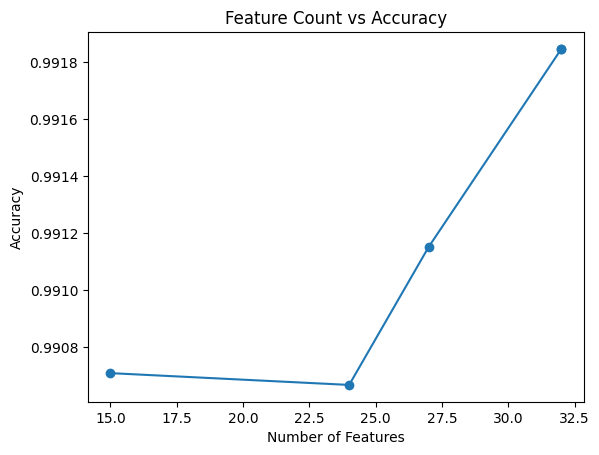

In [ ]:
import matplotlib.pyplot as plt

plt.plot(results_df["Features"], results_df["Accuracy"], marker='o')
plt.xlabel("Number of Features")
plt.ylabel("Accuracy")
plt.title("Feature Count vs Accuracy")
plt.show()

# FEATURE SELECTION (32 FEATURES)

In [ ]:
import pandas as pd

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

selected_features = feature_importance[feature_importance > 0.005].index

X_final = X[selected_features]

X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("=== MODEL WITH 32 FEATURES ===")
print("Accuracy:", accuracy_score(y_test, y_pred))

=== MODEL WITH 32 FEATURES ===
Accuracy: 0.9911523668639053


# FEATURE ENGINEERING

In [ ]:
data_fe = data.copy()

if 'Flow Duration' in data_fe.columns and 'Total Fwd Packet' in data_fe.columns:
    data_fe['packet_rate'] = data_fe['Total Fwd Packet'] / (data_fe['Flow Duration'] + 1)

if 'Total Length of Fwd Packet' in data_fe.columns and 'Flow Duration' in data_fe.columns:
    data_fe['byte_rate'] = data_fe['Total Length of Fwd Packet'] / (data_fe['Flow Duration'] + 1)

if 'Total Fwd Packet' in data_fe.columns and 'Total Backward Packet' in data_fe.columns:
    data_fe['packet_diff'] = data_fe['Total Fwd Packet'] - data_fe['Total Backward Packet']

if 'Total Fwd Packet' in data_fe.columns and 'Total Backward Packet' in data_fe.columns:
    data_fe['packet_ratio'] = data_fe['Total Fwd Packet'] / (data_fe['Total Backward Packet'] + 1)

if 'Flow Bytes/s' in data_fe.columns and 'Flow Packets/s' in data_fe.columns:
    data_fe['bytes_per_packet'] = data_fe['Flow Bytes/s'] / (data_fe['Flow Packets/s'] + 1)

print("Feature Engineering Done ✅")

Feature Engineering Done ✅


# RETRAIN AFTER FEATURE ENGINEERING

In [ ]:
X_fe = data_fe.drop("label", axis=1)
y_fe = data_fe["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=42
)

rf.fit(X_train, y_train)

# New feature importance
feature_importance_fe = pd.Series(rf.feature_importances_, index=X_fe.columns)
feature_importance_fe = feature_importance_fe.sort_values(ascending=False)

selected_features_fe = feature_importance_fe[feature_importance_fe > 0.005].index

X_final_fe = X_fe[selected_features_fe]

X_train, X_test, y_train, y_test = train_test_split(
    X_final_fe, y_fe, test_size=0.2, random_state=42
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("=== FINAL MODEL AFTER FEATURE ENGINEERING ===")
print("Features:", len(selected_features_fe))
print("Accuracy:", accuracy_score(y_test, y_pred))

=== FINAL MODEL AFTER FEATURE ENGINEERING ===
Features: 27
Accuracy: 0.9911523668639053


# SAVE FINAL DATASET

In [ ]:
data_fe.to_csv("final_engineered_dataset.csv", index=False)

print("Dataset saved ✅")